In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
def load_data():
    """
    Load revised final data from CSV.
    
    Args:
        station_id (int): Station number (1-6)
        
    Returns:
        pd.DataFrame
    """
    base_dir = Path("../data-cleanup/raw_merged_data")
    file_path = base_dir / "raw_merged_station_1.csv"
    df = pd.read_csv(file_path, index_col=0, parse_dates=True)
    return df

In [6]:
def df_fillna_middle_column(df, column):
  return df[column][df[column].bfill().notnull() & df[column].ffill().notnull()]

def fill_using_linear_interpolation(df):
  df_linear = df.copy()

  for col in df.columns:
    df_linear = df_linear.assign(**{ col: df_fillna_middle_column(df, col).fillna(df_linear[col].interpolate(option='linear')) })
  
  return df_linear

In [9]:
df = load_data()
df_not_2018 = df[df.index.year != 2018]
    

In [10]:
df_cleaned = fill_using_linear_interpolation(df_not_2018)

In [35]:
def analyze_cyclic_nature_tf(data, feature_name, sampling_rate=1):
    fft = tf.signal.rfft(data[feature_name])
    max_mag = np.max(np.abs(fft))
    
    f_per_dataset = np.arange(0, len(fft))
    n_samples_h = len(data[feature_name])
    hours_per_year = 24*365.2524
    years_per_dataset = n_samples_h/(hours_per_year)
    
    f_per_year = f_per_dataset/years_per_dataset
    
    plt.step(f_per_year, np.abs(fft))
    plt.xscale('log')
    plt.ylim(0, max_mag)
    plt.xlim([0.1, max(plt.xlim())])
    plt.xticks([1, 12, 365.2524], labels=['1/Year', '1/month', '1/day'])
    _ = plt.xlabel('Frequency (log scale)')
    plt.title(f'{feature_name} - FFT')
    plt.show()

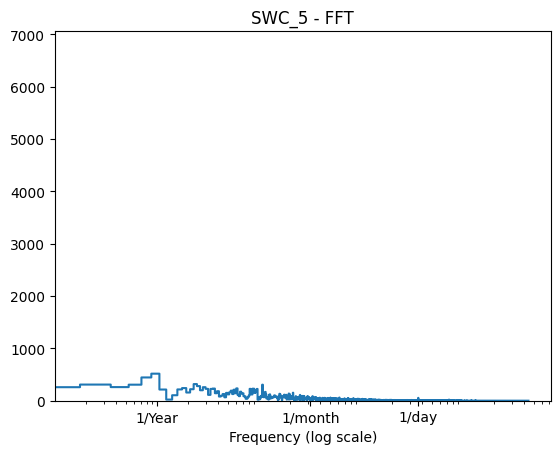

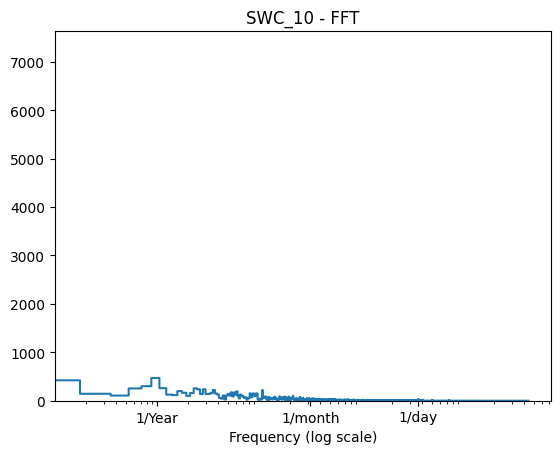

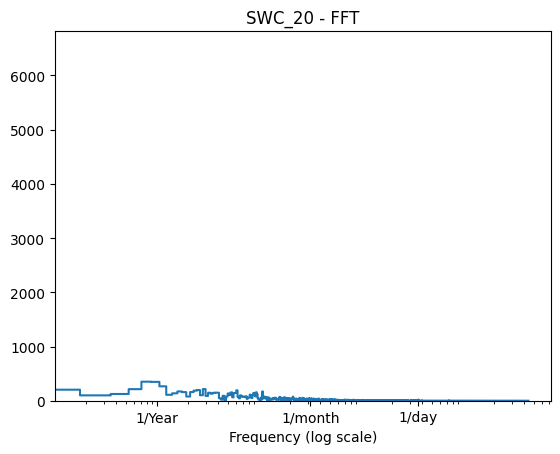

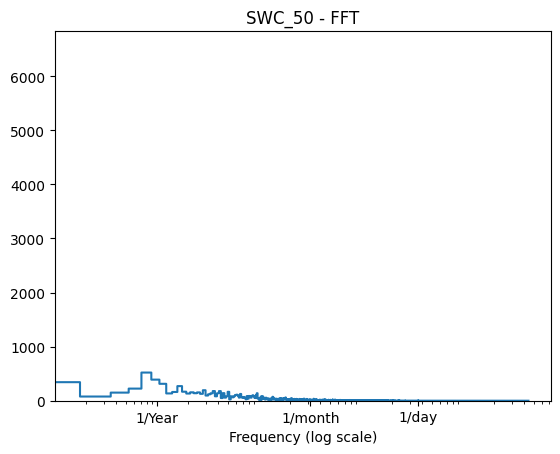

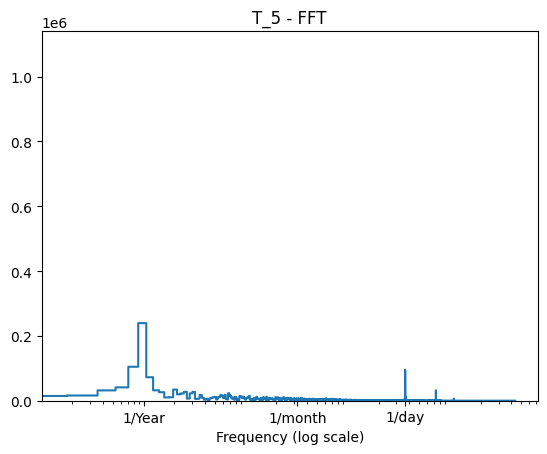

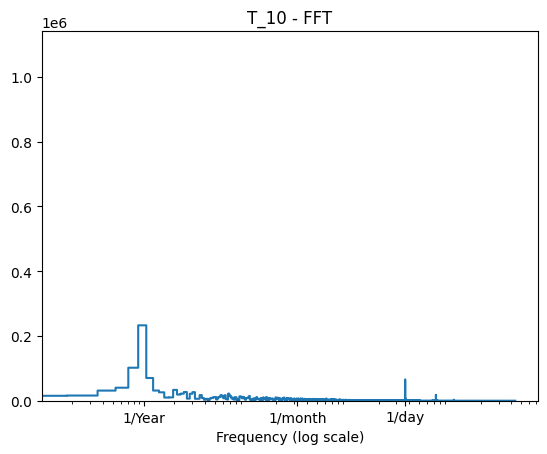

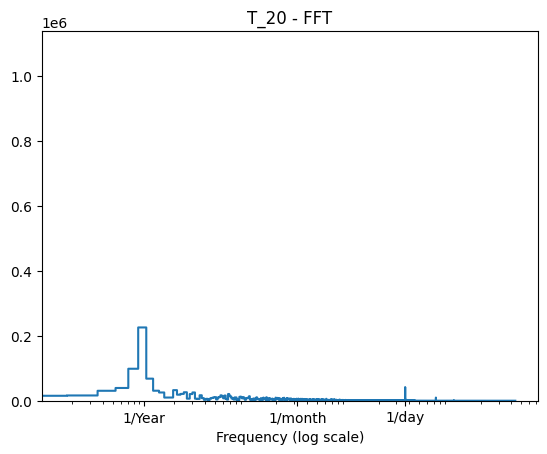

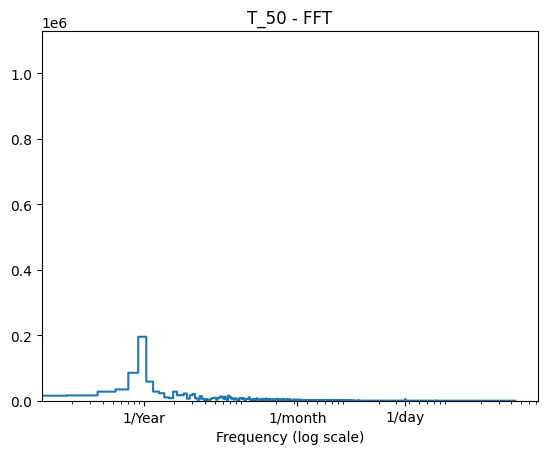

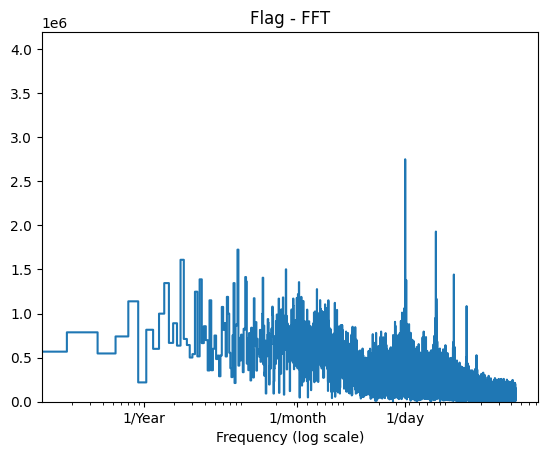

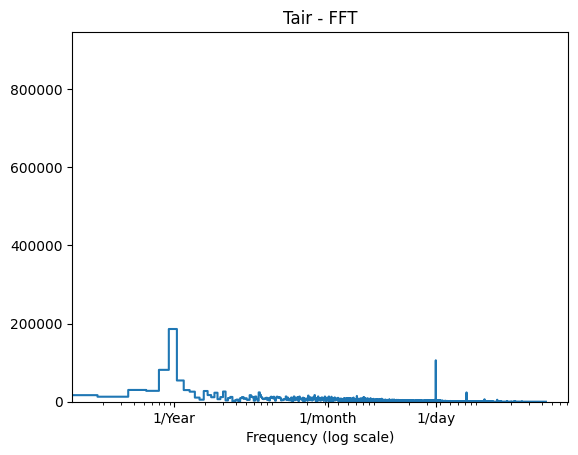

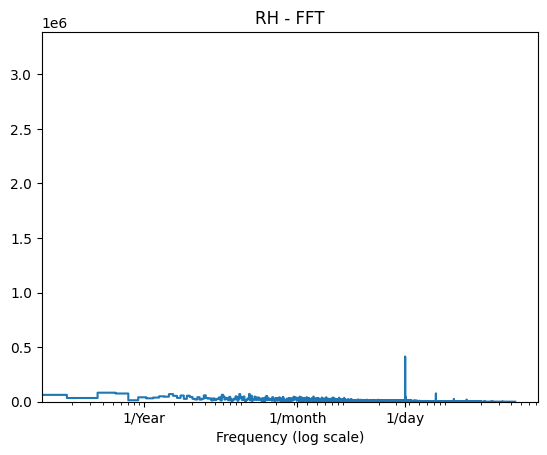

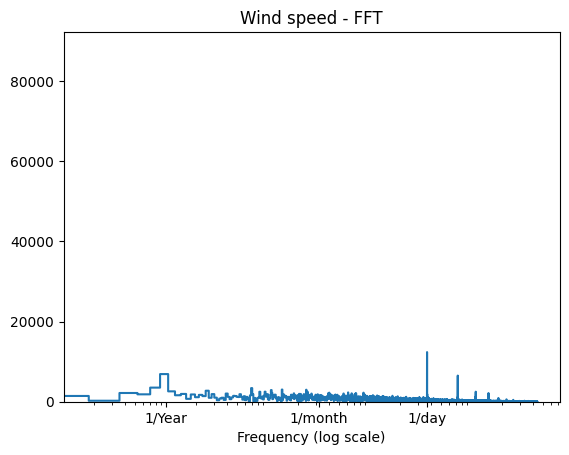

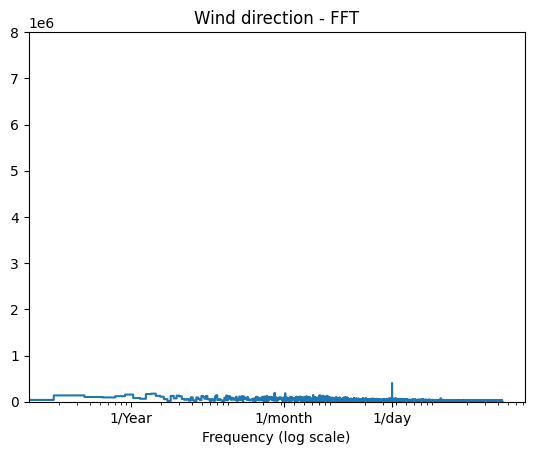

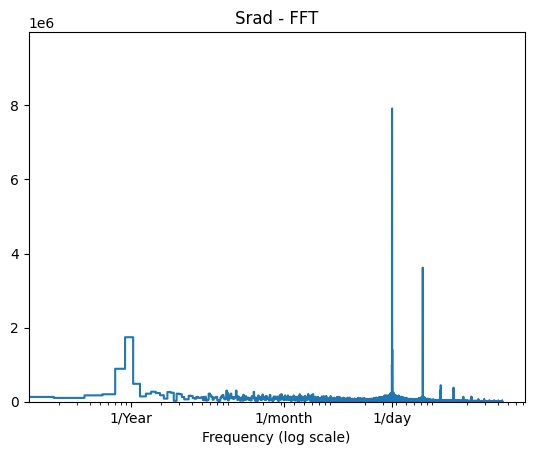

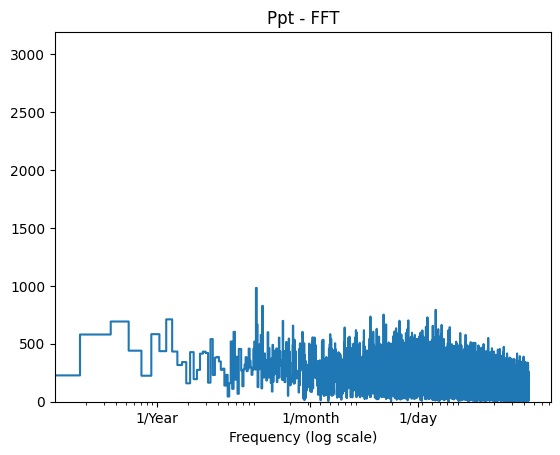

In [36]:
for col in df_cleaned.columns:
    analyze_cyclic_nature_tf(df_cleaned, col)